# Visualization Part 2: Starter Notebook

This notebook is a guided template for the individual visualization assignment.

You are expected to do more than make plots. You must explain whether your plot choices are clear, appropriate, honest, and interpretable.

Complete every section in order. Do not delete the prompts.


## What this notebook is testing

In this notebook, you must demonstrate that you can:

- choose a reasonable plot for a question
- use grouping or conditioning when needed
- think about scale carefully
- apply a transformation when it improves interpretation
- identify when a plot is misleading
- revise a weak plot into a stronger one
- explain what a plot shows in full sentences

A plot is not automatically good just because code produced it.


## Setup

Load the toy dataset first. Then inspect its structure before plotting anything.


In [43]:
# Import the libraries you need.
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load the toy dataset.
df = pd.read_csv("ethereum_messages_toy.csv")

# Display the first 5 rows.
display(df.head()) # replace by nicer table view

,message_type,sender_address,receiver_address,amount,transaction_flag,message_length
0,normal,0xaed548b0ad2ad42d36a65fc9fbb7365290273735,0xadebdbe4ffde843c5c0942476dafed98f4081ed2,12.7777,1,115
1,begging,0x380d92bab460b09297a542e4b0198e2c87e43c62,0x62afa887ea89b1b66c12e70d25de9412bdf3ddb4,1.5590,1,97
2,scam,0x87bd4dc83166db001549b0f7dd10ed8172a97987,0xc1d0a09e6109925ce9325a327c9bc34db8d33032,97.4377,1,210
3,normal,0xd5d04ef6b199bde888fc75394a7e49cbb2e35d4e,0x187b0ea64e520ab88273cce8678ddb6803c87968,6.0098,1,104
4,scam,0x5f8676e6b77d71e6dadf79e40929b9c9eb05f320,0x3e5a82554fb4ff75ee00ec09483e2ae03411d186,25.5839,1,103


## Initial inspection

Answer the following with code and short written notes:

1. How many rows and columns are in the dataset?
2. What are the data types?
3. Which columns are categorical?
4. Which columns are numerical?
5. Are there any columns that may need cleaning or special handling before plotting?


In [44]:
# Inspect the dataset using shape, info, describe, and any other helpful commands.

print("1. df.info()")
print(df.info())

print("\n2. df.shape")
print(df.shape)

print("\n3. df.describe()")
print(df.describe())

# Display column names
print("\n4. df.columns")
print(df.columns)

# Display 5 random samples
print("\n5. df.sample(5)")
print(df.sample(5))

# Check for missing values
print("\n6. df.isnull().sum()")
print(df.isnull().sum())

1. df.info()
<class 'pandas.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   message_type      1500 non-null   str    
 1   sender_address    1500 non-null   str    
 2   receiver_address  1500 non-null   str    
 3   amount            1500 non-null   float64
 4   transaction_flag  1500 non-null   int64  
 5   message_length    1500 non-null   int64  
dtypes: float64(1), int64(2), str(3)
memory usage: 70.4 KB
None

2. df.shape
(1500, 6)

3. df.describe()
            amount  transaction_flag  message_length
count  1500.000000       1500.000000     1500.000000
mean     14.214224          0.974667      126.264000
std      22.795458          0.157188       43.272948
min       0.635400          0.000000       15.000000
25%       3.437625          1.000000       96.000000
50%       7.411350          1.000000      122.000000
75%      14.532750          1.000000    

1. *How many rows and columns are in the dataset*: **1500 rows, 6 columns**
2. *What are the data types?*: **message_type**, **sender_address** and **receiver_address** are of type string, **amount** is float64, while **transaction_flag** and **message_length** are of int64 type
3. *Which columns are categorical?*: **message_type**, **sender_address**, and **receiver_address**
4. *Which columns are numerical?*: **amount**, **transaction_flag**, and **message_length**
5. *Are there any columns that may need cleaning or special handling before plotting?*: There are no missing values, and the existing data seems good. At least one transaction might be quite high compared to the mean (*mean is 14.21, while the max value shows 276.11*), but it is not clear, if this value is an outlier or just an unregular large value. While the collection method itself could have problems or biases, the dataset as represented here seems to work very good already for plotting

# Part B: Redo Two Visualizations from Phase 2


Return to your own project dataset.

Select **two** plots from your Phase 2 work and redo them.

You may not simply paste the same plot again. You must improve them.

Possible improvements include:

- better scale
- transformation
- clearer grouping
- better ordering of categories
- better labels
- better titles
- better readability
- a more appropriate plot type

For each revised plot, include:

- the original Phase 2 question
- the revised plot
- a short paragraph explaining what was weak in the original version
- a short paragraph explaining what you changed and why it is better

Additional requirement:

- At least one revised plot must include a change in scale, transformation, or grouping.
- Cosmetic changes alone will not receive credit.



/tmp/ipykernel_46331/3244023661.py:2: DtypeWarning: Columns (0: Phase, 1: MajorityVaccinated) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv("dataset/merged_dataset.csv")


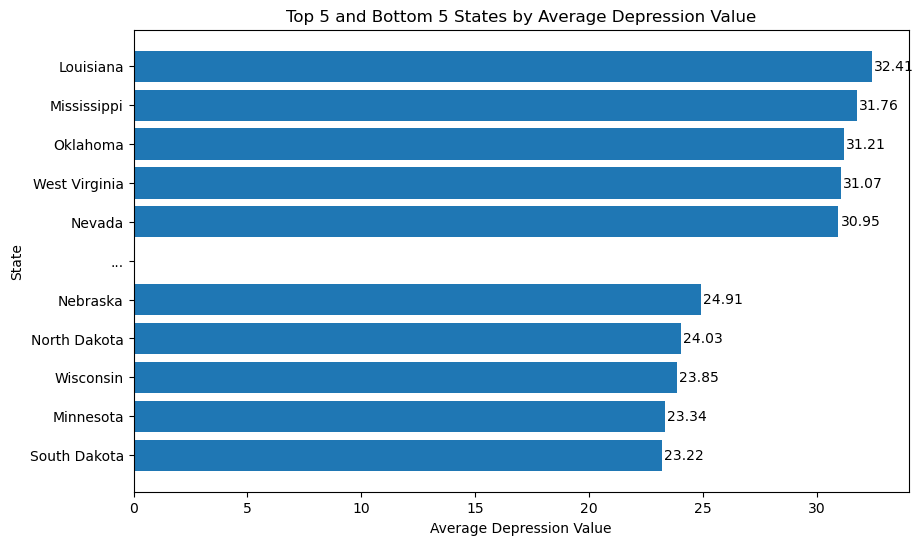

In [67]:
# Load your project dataset for Part B.
data = pd.read_csv("dataset/merged_dataset.csv")
# ! This dataset was produced by the "project-phase2.ipynb" notebook. To run this notebook here again, make sure to run "project-phase2.ipynb" first to generate the "merged_dataset.csv" file.

# Redo the first plot from Phase 2 here.

# Get average depression value per state
state_avg = (
    data[['State', 'Value']]
    .dropna()
    .groupby('State')['Value']
    .mean()
    .sort_values(ascending=False)
)

# Get top 5 and bottom 5 states by average depression value
top5 = state_avg.head(5)
bottom5 = state_avg.tail(5)

# Combine top 5 and bottom 5 states with a gap in between
gap = pd.Series([0], index=["..."])
combined = pd.concat([top5, gap, bottom5])

# Plot the combined top 5 and bottom 5 states
plt.figure(figsize=(10,6))
plt.barh(combined.index[::-1], combined.values[::-1])

# # Add value labels to each bar
# Enumerate through the states to add the value labels (skips the "...")
for i, (label, v) in enumerate(zip(combined.index[::-1], combined.values[::-1])):
    if label != "...":
        plt.text(v + 0.1, i, f"{v:.2f}", va='center')

plt.title('Top 5 and Bottom 5 States by Average Depression Value')
plt.xlabel('Average Depression Value')
plt.ylabel('State')

plt.show()


*"Which U.S. state had the highest average depression value?"*

The original plot listed all states with their average depression value, with the states being on the x-axis and the average value on the y-axis. While it already allowed to draw conclusions, the sheer number of states made it hard to interpret. As the individual bars did not include an additional label for each bar, the concrete value had to be estimated, which was also quite hard because of the many listed states.

This new, revised version switches to a horizontal bar chart, and only includes the 5 states with the highest, and the 5 states with the lowest average depression value. It also includes a label with the exact value for each bar. These changes make the plot easier to read and highlight the most relevant extremes in the data more clearly. The added labels also allow us to read off the associated values directly, removing the need to estimate them from the x-axis. The tradeoff is that this version no longer shows the states in between, so it is less useful for comparing all states at once.

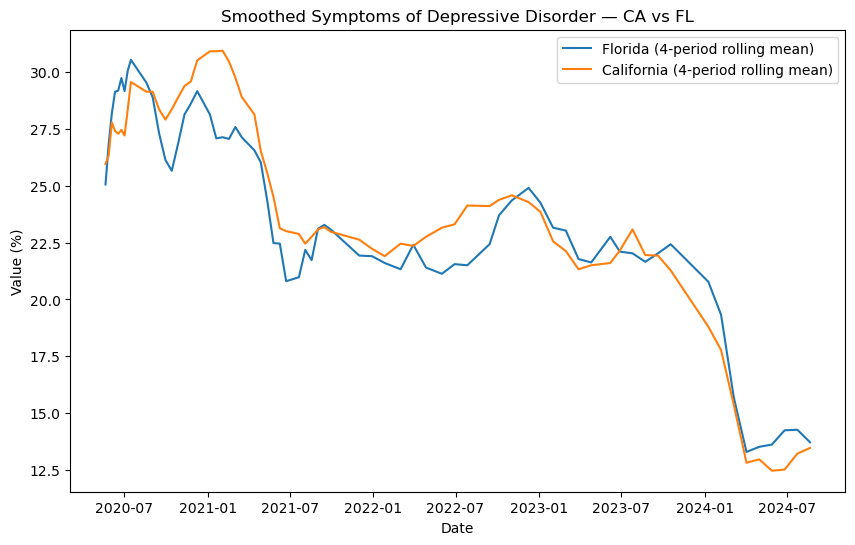

In [ ]:
# Redo the second plot from Phase 2 here.

# Original code from Phase 2
x = data[(data["Indicator"]=="Symptoms of Depressive Disorder") &
        (data["Group"]=="By State") &
        (data["State"].isin(["California","Florida"]))].copy()

x["date"] = pd.to_datetime(x["Time Period Start Date"].astype(str), format="%Y%m%d", errors="coerce")
x["Value"] = pd.to_numeric(x["Value"], errors="coerce")

wide = x.dropna(subset=["date","Value"]).pivot_table(index="date", columns="State", values="Value", aggfunc="mean").sort_index()

# Add smoothed versions
# Averages over 4 values
wide["California_smooth"] = wide["California"].rolling(window=4).mean()
wide["Florida_smooth"] = wide["Florida"].rolling(window=4).mean()

# Plot
plt.figure(figsize=(10,6)) # Figure size
plt.plot(wide.index, wide["Florida_smooth"], label="Florida (4-period rolling mean)") # Florida
plt.plot(wide.index, wide["California_smooth"], label="California (4-period rolling mean)") # Cal

plt.title("Smoothed Symptoms of Depressive Disorder — CA vs FL")
plt.xlabel("Date")
plt.ylabel("Value (%)")
plt.legend()
plt.show()

*"How do depression trends over time differ between California and Florida?"*

In the original visualization, the plot showed us a very detailed line chart. While it is great at capturing details, the many short-term fluctuations and detailed values make it hard to read fast. Variances can lead to sharp peaks or sharp declines, making outliers and large values stand out, which can make interpreting long-term trends harder to read.

The new visualization keeps the same core idea - compare California's depression rate with Florida's rate through a line chart. But now, we use smooth values with a window of 4, which takes the average of that point and the previous three values in the window. With that, we create a smoother line graph, where the outliers or values with larger variance do not lead to such sharp spikes or declines. This makes it easier to detect long-term trends, as well as comparisons over different periods of time. The only information lost are detailed local differences of our data values. To analyze them, it is recommended to use plots that zoom into the time frame that should be analyzed in greater detail.

# Part C: Specific Questions About Your Project


Use your own project dataset to answer the following required questions.


## Part C, Question 1: Comparison with conditioning

Choose one categorical variable and one numerical variable from your project.

Create a plot that answers this question:

**Which groups differ the most on this numerical variable?**

Requirements:
- You must use grouping or conditioning.
- You must explain how the data was aggregated, if aggregation was used.

                      Indicator             Group         State      Subgroup Phase  Time Period    Time Period Label  Time Period Start Date  Time Period End Date  Value  Low CI  High CI Confidence Interval Quartile Range  C1M_combined_numeric  C2M_combined_numeric  C3M_combined_numeric  C4M_combined_numeric  C5M_combined_numeric  C6M_combined_numeric  C7M_combined_numeric  C8EV_combined_numeric  E1_combined_numeric  E2_combined_numeric  H1_combined_numeric  H2_combined_numeric  H3_combined_numeric  H6M_combined_numeric  H7_combined_numeric  H8M_combined_numeric  V1..summary.  V2..summary.  V3..summary.  V4..summary.  ConfirmedCases  ConfirmedDeaths  PopulationVaccinated  StringencyIndex_Average  GovernmentResponseIndex_Average  ContainmentHealthIndex_Average  EconomicSupportIndex MajorityVaccinated
Symptoms of Depressive Disorder National Estimate United States United States     1            1 Apr 23 - May 5, 2020                20200423              20200505   23.5    22.7     24.3 

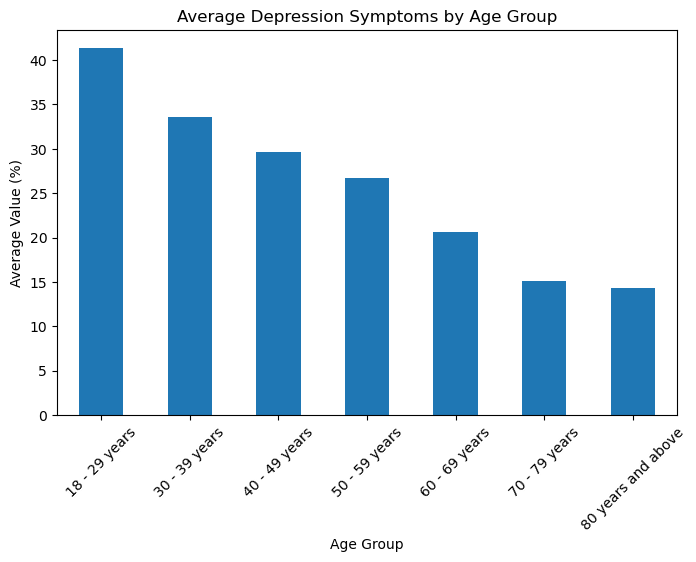

In [104]:
# Create the comparison plot for your project dataset.

# First print out nicely the first 5 rows of the dataset
print(data.head().to_string(index=False))

# Filter to only age groups
age_df = data[data["Group"] == "By Age"]

# Aggregate the average Value per age group
age_agg = age_df.groupby("Subgroup")["Value"].mean().sort_values(ascending=False)

# Plot the aggregated values
plt.figure(figsize=(8,5))
age_agg.plot(kind="bar")
plt.title("Average Depression Symptoms by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Average Value (%)")
plt.xticks(rotation=45)
plt.show()


After the plot, write 4 to 6 full sentences answering:

1. What are the groups?
2. What numerical variable are you comparing?
3. What method did you use to summarize the data?
4. Which groups stand out most?
5. Is the comparison easy to interpret?


*"Which age subgroup has the largest average depression symptoms?"*

The groups are the individuals that participated in the depression and anxiety survey, categorized by their age. The numerical variable is the average depression value. I used a groupby operation to summarize the data and calculate the average of each group. The group that stands out the most is the "18-29 years" group, which has an incredibly high value of over 40% of depression symptoms. It is quite easy to read, as there are not too many groups and their differences are large enough to be clearly visible, without further transformation. To improve readability of the associated values, one improvement could be to include the average value for the groups for each bar.

## Part C, Question 2: Distribution and transformation

Choose one important numerical variable from your project.

Create:

- one original distribution plot
- one transformed version of that plot


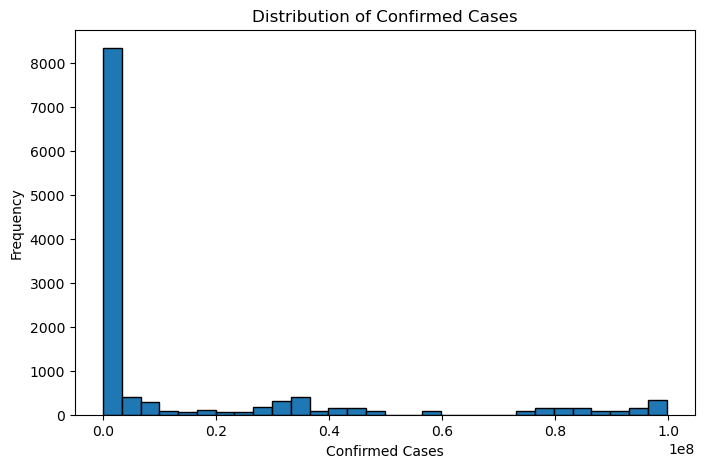

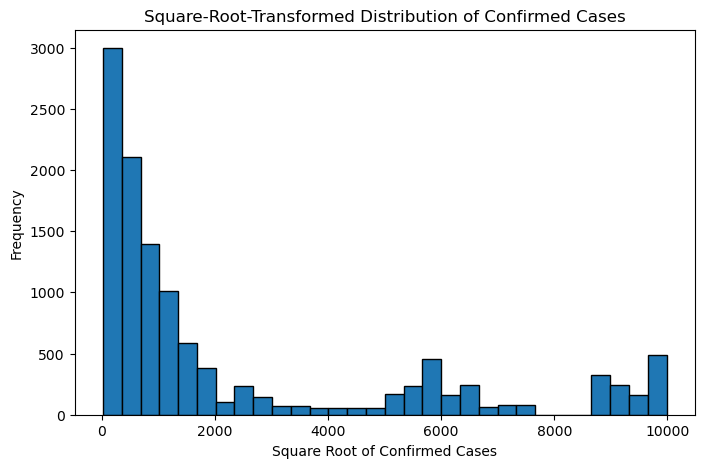

In [117]:
# Create the original and transformed distribution plots for your project dataset.
values = pd.to_numeric(data["ConfirmedCases"], errors="coerce").dropna()

# First plot
plt.figure(figsize=(8,5))
plt.hist(values, bins=30, edgecolor="k")
plt.title("Distribution of Confirmed Cases")
plt.xlabel("Confirmed Cases")
plt.ylabel("Frequency")
plt.show()

# Second Plot: Square-Root-Transformed Distribution
sqrt_values = np.sqrt(values)

plt.figure(figsize=(8,5))
plt.hist(sqrt_values, bins=30, edgecolor="k")
plt.title("Square-Root-Transformed Distribution of Confirmed Cases")
plt.xlabel("Square Root of Confirmed Cases")
plt.ylabel("Frequency")
plt.show()



After the plots, write 4 to 6 full sentences answering:

1. What does the original distribution look like?
2. Does the variable appear skewed or spread out?
3. Why did you choose this transformation?
4. What does the transformed version reveal more clearly?
5. Which version would you show to a reader, and why?

The original distribution shows the frequency of confirmed COVID-19 cases across the dataset. Many observations have low values, while a smaller number of observations have very large values, making the distribution heavily right-skewed. The square root transformation reduces the impact of these large values and spreads out the smaller ones, making their differences more visible. As a result, the transformed version reveals the overall structure of the data more clearly and makes it easier to compare different ranges of confirmed cases. In most cases, I would prefer to show the transformed version to a reader, as it improves interpretability. The original version can still be useful when you want to demonstrate how many records actually do not have any confirmed cases.


## Part C, Question 3: Scale and misleading design

Create one plot from your project that could be misleading if scaled badly.

Then:
- create the misleading version
- create the corrected version

After the plots, write 4 to 6 full sentences answering:
1. What scaling choice made the first plot misleading?
2. Why is that misleading?
3. How did you fix it?
4. What is the main lesson from this example?


['Indicator', 'Group', 'State', 'Subgroup', 'Phase', 'Time Period', 'Time Period Label', 'Time Period Start Date', 'Time Period End Date', 'Value', 'Low CI', 'High CI', 'Confidence Interval', 'Quartile Range', 'C1M_combined_numeric', 'C2M_combined_numeric', 'C3M_combined_numeric', 'C4M_combined_numeric', 'C5M_combined_numeric', 'C6M_combined_numeric', 'C7M_combined_numeric', 'C8EV_combined_numeric', 'E1_combined_numeric', 'E2_combined_numeric', 'H1_combined_numeric', 'H2_combined_numeric', 'H3_combined_numeric', 'H6M_combined_numeric', 'H7_combined_numeric', 'H8M_combined_numeric', 'V1..summary.', 'V2..summary.', 'V3..summary.', 'V4..summary.', 'ConfirmedCases', 'ConfirmedDeaths', 'PopulationVaccinated', 'StringencyIndex_Average', 'GovernmentResponseIndex_Average', 'ContainmentHealthIndex_Average', 'EconomicSupportIndex', 'MajorityVaccinated']


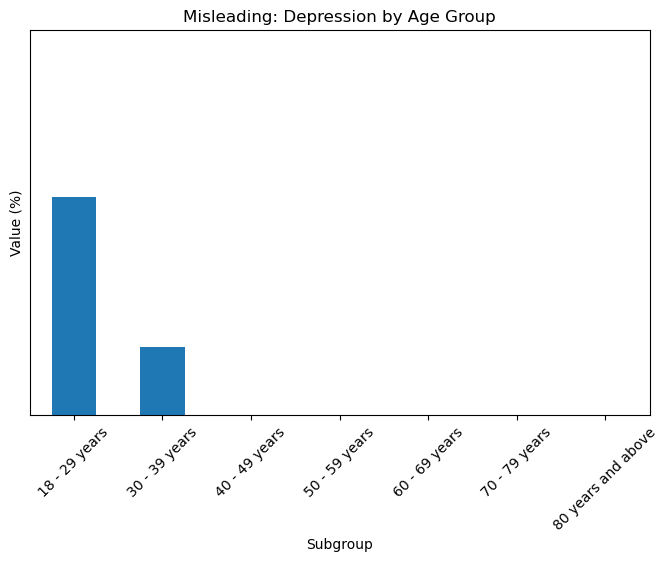

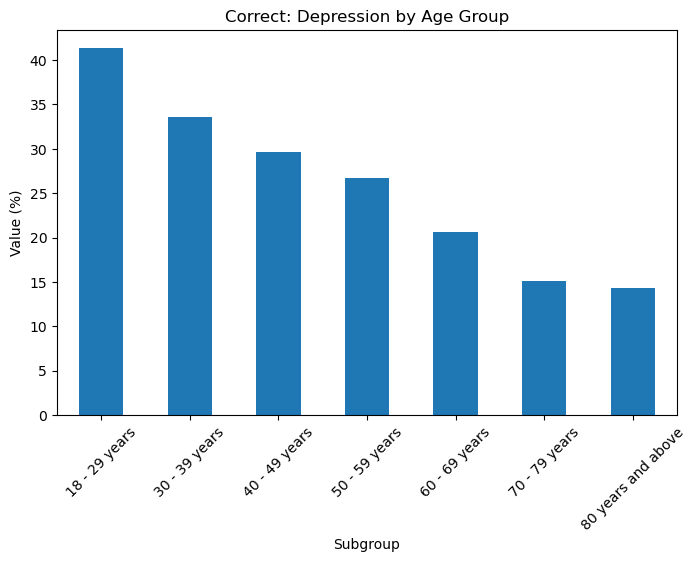

In [125]:
# Create a misleading project plot and then fix it.
print(data.columns.tolist())

age_df = data[data["Group"] == "By Age"]
age_summary = age_df.groupby("Subgroup")["Value"].mean()

plt.figure(figsize=(8,5))
age_summary.plot(kind="bar")

plt.ylim(30, 50) # zoomed in, misleading
plt.yticks([])  # remove y-axis ticks
plt.title("Misleading: Depression by Age Group")
plt.ylabel("Value (%)")
plt.xticks(rotation=45)
plt.show()

###########
# Corrected plot
plt.figure(figsize=(8,5))
age_summary.plot(kind="bar")

plt.title("Correct: Depression by Age Group")
plt.ylabel("Value (%)")
plt.xticks(rotation=45)
plt.show()

After the plots, write 4 to 6 full sentences answering:

1. What scaling choice made the first plot misleading?
2. Why is that misleading?
3. How did you fix it?
4. What is the main lesson from this example?

The first version restricted the y-axis values range from 30.0 to 50.0, and removed the associated ticks with that axis. This is very misleading, as it now seems like the younger age groups of "18-29 years" and "30-39 years" have some recorded depression, while the other age groups have no depression at all (*or very small values that can not be easily seen*). As we see in the corrected plot, this is not true at all. To fix this, we just need to restore the full y-axis again, so we start at 0% and add the value ticks again. This example clearly shows how zooming into a plot can have a huge impact on what conclusions the viewer can draw from it, and that missing labels and label values make it very hard to identify this manipulation.


## Part C, Question 4: Communication and context

Take one of your project plots and improve it for communication.

Your improved version must include:
- a meaningful title
- clear axis labels
- readable categories or ticks
- a short caption of 2 to 4 sentences

Your caption must explain:
- what the plot shows
- one important takeaway
- why the plot is useful for your project question


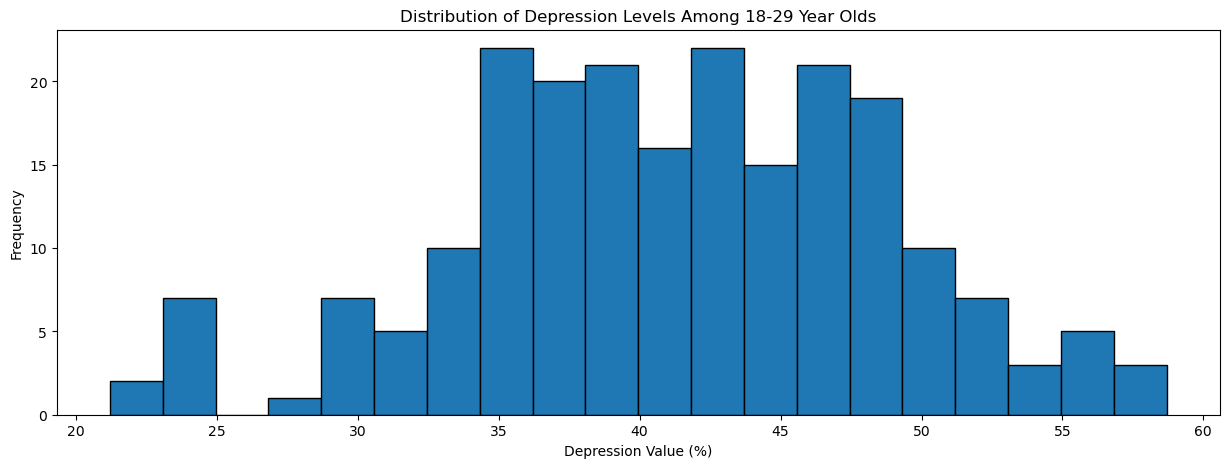

In [123]:
# Create a polished version of one of your project plots.
g = data.loc[data["Subgroup"].eq("18 - 29 years"), "Value"]
g = pd.to_numeric(g, errors="coerce").dropna()

plt.figure(figsize=(15,5))

plt.hist(g, bins=20, edgecolor='black')

plt.title("Distribution of Depression Levels Among 18-29 Year Olds")
plt.xlabel("Depression Value (%)")
plt.ylabel("Frequency")

plt.show()

*Caption*: This plot shows the distribution of reported depression values for individuals aged 18–29 across all time periods in the dataset. Most values are concentrated between approximately 30% and 50%, indicating consistently large levels of depressive symptoms in this age group. A key takeaway is that younger individuals tend to report relatively high depression levels, with fewer observations at very low values. This visualization is useful for the project because it highlights the mental health burden among younger populations, which may be influenced by external factors such as pandemic-related policies.

# Part D: Reflection

Write one full paragraph answering the following:

- What did you learn about visualization from this assignment?
- What mistake were you making before?
- How did scale, transformation, or conditioning change your interpretation?
- What did you learn from intentionally making a misleading plot?

This assignment taught me how transformation, labeling, and scale can improve readability and interpretability of graphs. Previously the visualizations from our project were correctly visualizing the content, but they were hard to read, either because they included too many values, were not labeled enough, or the raw data resulted in too detailed graphs. For example, in Part A, I initially used the raw amount distribution, which made the histogram hard to interpret due to heavy skew. Applying a transformation made the structure clearer. While the interpretations in our project remain the same, the improved visualizations allow to come faster to conclusions and make us more confident in our interpretations. We also learned how misleading plots can be created and detected. In the assignment I realized how easy it is to make misleading plots, how they might be hard to recognize, and can completely flip around the drawn conclusions.